# AGN corona spectral fitting with current cosipy

This notebook updates the older `AGN_XRay` AGN corona workflow to the current cosipy/3ML fitting pattern used by the Crab spectral fitting tutorial. It expects the DC4 mock data set to already be binned into a cosipy/histpy HDF5 file. If you want time selections, apply them before binning the data supplied here.

The fit can include NGC 4151 and/or NGC 1068. Each source is modeled as a cutoff-power-law thermal component, with an optional simple-power-law non-thermal tail.

In [1]:
from pathlib import Path
import sys

analysis_dir = Path.cwd()
if not (analysis_dir / "agn.yaml").exists():
    repo_notebook_dir = Path("/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN")
    if repo_notebook_dir.exists():
        analysis_dir = repo_notebook_dir

from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedThreeMLModelFolding,
    BinnedInstrumentResponse,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.data_io import EmCDSBinnedData

from histpy import Histogram

import astropy.units as u
from astropy.coordinates import SkyCoord

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Cutoff_powerlaw, Powerlaw, Line

%matplotlib inline


17:14:09 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=14547;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=195063;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=337112;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=566933;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=160846;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=783813;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

17:14:10 INFO      Starting 3ML!                                                                     ]8;id=194969;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=670508;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=789325;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=307713;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=963359;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=324184;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

17:14:11 WARNING   No fermitools installed                                              ]8;id=914494;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=42724;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=558257;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=641410;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=723001;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=332222;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=927544;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=531137;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Paths and run options

Set `binned_mock_data_file` to the HDF5 file you create from the full mock unbinned data set, or to a file you already cut before binning. The notebook does not apply time selections internally.

In [10]:
binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered.hdf5")

total_background_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5"
)

agn_config = analysis_dir / "agn.yaml"
exposure_multiplier = 3
# Match the older AGN_Corona_Paper_Plots convention: the multiplier scales
# the simulated count histograms and the injected/reference flux normalization.

# Fit controls. Use ["ngc4151", "ngc1068"] and True to restore the
# two-source thermal plus non-thermal joint fit.
fit_source_names = ["ngc4151"]
fit_include_nonthermal_tail = False

source_settings = {
    "ngc4151": {
        "label": "NGC 4151",
        "l": 155.07 * u.deg,
        "b": 75.06 * u.deg,
        "thermal_K_at_1keV": 0.15 / (u.cm * u.cm * u.s * u.keV),
        "thermal_index": -1.75,
        "thermal_cutoff": 200 * u.keV,
        "tail_ratio_at_200keV": 0.15,
        "tail_index": -3.8,
    },
    "ngc1068": {
        "label": "NGC 1068",
        "l": 17.2 * u.deg,
        "b": -51.9 * u.deg,
        "thermal_K_at_1keV": 3.1e-1 / (u.cm * u.cm * u.s * u.keV),
        "thermal_index": -1.92,
        "thermal_cutoff": 200 * u.keV,
        "tail_ratio_at_200keV": 0.15,
        "tail_index": -3.8,
    },
}

fit_source_names = list(fit_source_names)
if not fit_source_names:
    raise ValueError("fit_source_names must contain at least one source")
unknown_fit_sources = set(fit_source_names) - set(source_settings)
if unknown_fit_sources:
    raise ValueError(f"Unknown fit source name(s): {sorted(unknown_fit_sources)}")

reference_flux_multiplier = exposure_multiplier
count_exposure_multiplier = exposure_multiplier

source_coords = {
    name: SkyCoord(l=settings["l"], b=settings["b"], frame="galactic")
    for name, settings in source_settings.items()
}


## Spacecraft file and response

This follows the same current response-loading pattern as the Crab spectral fitting notebook. If you already have local response/orientation files, replace these paths and skip the downloads.

In [3]:
orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
# fetch_wasabi_file(
#     "COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori",
#     output=str(orientation_path),
#     checksum="416fcc296fc37a056a069378a2d30cb2",
# )
sc_orientation = SpacecraftHistory.open(orientation_path)

response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
# fetch_wasabi_file(
#     "COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5",
#     output=str(response_path),
#     checksum="7121f094be50e7bfe9b31e53015b0e85",
# )
dr = FullDetectorResponse.open(str(response_path))


## Load binned data and total background

The binned mock data already include background. The separate total-background file is loaded as the background template for the likelihood and projected over all time bins present in the file. No additional time selections are applied in this notebook.

In [4]:
if not binned_mock_data_file.exists():
    raise FileNotFoundError(
        f"Set binned_mock_data_file to your binned mock data HDF5 file: {binned_mock_data_file}"
    )

agn = BinnedData(agn_config)
agn.load_binned_data_from_hdf5(binned_data=binned_mock_data_file)
total_background = Histogram.open(total_background_file)

data_hist = agn.binned_data.project("Em", "Phi", "PsiChi") * count_exposure_multiplier
total_bkg = total_background.project("Em", "Phi", "PsiChi") * count_exposure_multiplier
bkg_dist = {"total_bkg": total_bkg}

for label in bkg_dist:
    bkg_dist[label] += sys.float_info.min

# Backward-compatible aliases for plotting cells that use source names.
data_hists = {name: data_hist for name in fit_source_names}
total_bkgs = {name: total_bkg for name in fit_source_names}
bkg_dists = {name: bkg_dist for name in fit_source_names}
fit_sc_orientation = sc_orientation

## Counts vs energy

This is the Crab-notebook style count-space diagnostic before fitting: the binned mock data, which already include background, and the total-background template are projected onto measured energy without additional notebook-side time cuts.

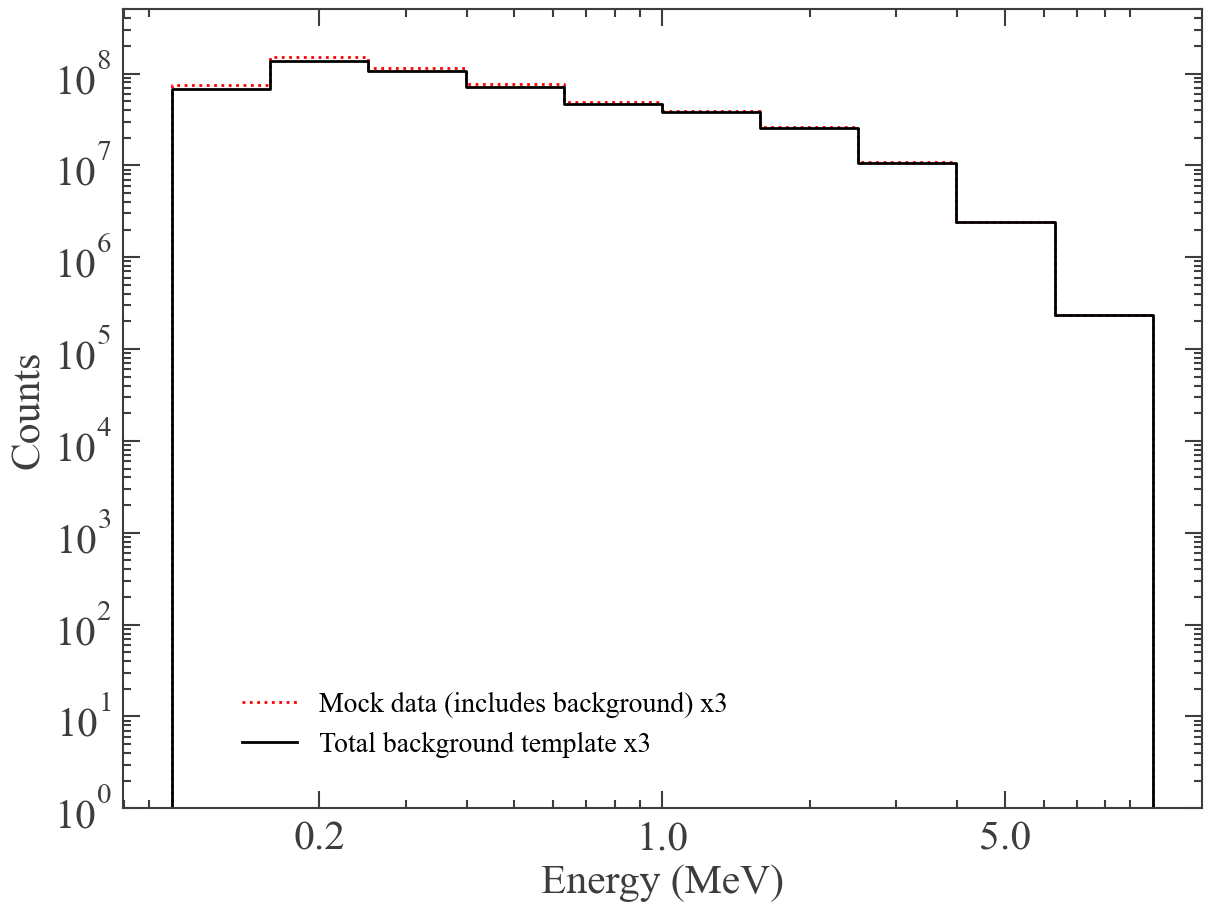

In [5]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000

plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top="on", pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top="on", pad=8)
ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right="on", pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right="on", pad=8)

ax.spines["right"].set_visible(True)
ax.spines["top"].set_visible(True)

colors = {"mock": "red", "background": "black"}
data_hist.project("Em").draw(
    ax,
    label=f"Mock data (includes background) x{count_exposure_multiplier:g}",
    color=colors["mock"],
    linestyle="dotted",
)
total_bkg.project("Em").draw(
    ax,
    label=f"Total background template x{count_exposure_multiplier:g}",
    color=colors["background"],
    linestyle="solid",
)
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1, 5e8)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc=(0.1, 0.05), frameon=False)
plt.show()

## COSI 3ML plugin

In [11]:
def build_cosi_plugin(plugin_name, data_hist, bkg_dist, sc_history):
    data = EmCDSBinnedData(data_hist)
    bkg = FreeNormBinnedBackground(bkg_dist, sc_history=sc_history, copy=False)

    instrument_response = BinnedInstrumentResponse(dr, data)
    psr = BinnedThreeMLPointSourceResponse(
        data=data,
        instrument_response=instrument_response,
        sc_history=sc_history,
        energy_axis=dr.axes["Ei"],
        polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
        nside=2 * data.axes["PsiChi"].nside,
    )
    response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)
    like_fun = PoissonLikelihood(data, response, bkg)
    plugin = ThreeMLPluginInterface(plugin_name, like_fun, response, bkg)

    for bkg_label in bkg_dist:
        plugin.bkg_parameter[bkg_label] = Parameter(
            bkg_label,
            1.0,
            min_value=0.0,
            max_value=100.0,
            delta=0.05,
            unit=u.Hz,
        )

    return plugin, response, bkg

cosi_plugin, response, background_model = build_cosi_plugin(
    "cosi",
    data_hist,
    bkg_dist,
    fit_sc_orientation,
)
cosi_plugins = {"cosi": cosi_plugin}
responses = {"cosi": response}
background_models = {"cosi": background_model}


## Source model

The fit is controlled by `fit_source_names` and `fit_include_nonthermal_tail` in the setup cell. The current default fits only NGC 4151 with the cutoff-power-law thermal component. Set `fit_source_names = ["ngc4151", "ngc1068"]` and `fit_include_nonthermal_tail = True` to restore the two-source thermal plus non-thermal joint model.

In [12]:
def make_cutoff_powerlaw(K, piv, xc, index):
    spectrum = Cutoff_powerlaw()
    spectrum.K.value = K.to_value(1 / (u.cm * u.cm * u.s * u.keV))
    spectrum.piv.value = piv.to_value(u.keV)
    spectrum.xc.value = xc.to_value(u.keV)
    spectrum.index.value = index
    spectrum.K.unit = K.unit
    spectrum.piv.unit = piv.unit
    spectrum.xc.unit = xc.unit
    return spectrum


def make_powerlaw_tail(thermal_spectrum, ratio, tail_index=-3.8, pivot=200 * u.keV):
    tail = Powerlaw()
    K = ratio * thermal_spectrum.evaluate_at(pivot.to_value(u.keV)) / (u.cm * u.cm * u.s * u.keV)
    tail.K.value = K.value
    tail.piv.value = pivot.to_value(u.keV)
    tail.index.value = tail_index
    tail.K.unit = K.unit
    tail.piv.unit = pivot.unit
    return tail

In [13]:
reference_spectra = {}
model_sources = []
component_source_names = []

for name, settings in source_settings.items():
    reference_thermal = make_cutoff_powerlaw(
        K=settings["thermal_K_at_1keV"] * reference_flux_multiplier,
        piv=1 * u.keV,
        xc=settings["thermal_cutoff"],
        index=settings["thermal_index"],
    )
    reference_tail = make_powerlaw_tail(
        reference_thermal,
        ratio=settings["tail_ratio_at_200keV"],
        tail_index=settings["tail_index"],
    )
    reference_spectra[name] = {
        "thermal": reference_thermal,
        "tail": reference_tail,
        "total": reference_thermal + reference_tail,
    }

    if name not in fit_source_names:
        continue

    thermal_K_at_200 = reference_thermal.evaluate_at(200.0) / (u.cm * u.cm * u.s * u.keV)
    thermal = make_cutoff_powerlaw(
        K=thermal_K_at_200,
        piv=200 * u.keV,
        xc=settings["thermal_cutoff"],
        index=settings["thermal_index"],
    )
    thermal.index.fix = True
    thermal.K.min_value = 1e-8
    thermal.K.max_value = 1e-2
    thermal.xc.min_value = 100
    thermal.xc.max_value = 10000
    # thermal.xc.delta = 10

    thermal_source_name = f"{name}_thermal"
    thermal_source = PointSource(
        thermal_source_name,
        l=settings["l"].value,
        b=settings["b"].value,
        spectral_shape=thermal,
    )
    model_sources.append(thermal_source)
    component_source_names.append(thermal_source_name)

    if fit_include_nonthermal_tail:
        tail = Powerlaw()
        tail.K.value = max(reference_tail.evaluate_at(200.0), 1e-12)
        tail.piv.value = 200.0
        tail.index.value = settings["tail_index"]
        tail.K.unit = 1 / (u.cm * u.cm * u.s * u.keV)
        tail.piv.unit = u.keV
        tail.K.min_value = 1e-8
        tail.K.max_value = 1e-2
        tail.index.min_value = -5
        tail.index.max_value = 1
        # tail.index.delta = 0.25

        tail_source_name = f"{name}_tail"
        tail_source = PointSource(
            tail_source_name,
            l=settings["l"].value,
            b=settings["b"].value,
            spectral_shape=tail,
        )
        model_sources.append(tail_source)
        component_source_names.append(tail_source_name)

model = Model(*model_sources)

if fit_include_nonthermal_tail:
    for name in fit_source_names:
        settings = source_settings[name]
        link_function = Line(a=0.0, b=settings["tail_ratio_at_200keV"])
        link_function.a.fix = True
        link_function.b.fix = True
        model.link(
            getattr(model, f"{name}_tail").spectrum.main.Powerlaw.K,
            getattr(model, f"{name}_thermal").spectrum.main.Cutoff_powerlaw.K,
            link_function,
        )

## Fit

In [14]:
plugins = DataList(*cosi_plugins.values())
like = JointLikelihood(model, plugins, verbose=False)
fit_result = like.fit()

17:17:31 INFO      set the minimizer to minuit                                             ]8;id=178622;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=983643;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

17:17:50 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=310790;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=3784;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=873199;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=924105;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Best fit values:

,result,unit
parameter,,
ngc4151_thermal.spectrum.main.Cutoff_powerlaw.K,(1.592 +/- 0.011) x 10^-3,1 / (keV s cm2)
ngc4151_thermal.spectrum.main.Cutoff_powerlaw.xc,(1.536 +/- 0.008) x 10^2,keV
total_bkg,(8.2241 +/- 0.0004) x 10,Hz


...

1.00,-0.91,-0.04
-0.91,1.00,-0.21
-0.04,-0.21,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-4119679798.849432
total,-4119679798.849432


Values of statistical measures:

,statistical measures
AIC,-8239359591.69876
BIC,-8239359560.656147


In [15]:
bkg_rate = like.results.optimized_model["total_bkg"].value
bkg_livetime = np.sum(fit_sc_orientation.livetime).to_value(u.s)
bkg_counts_from_fit = bkg_rate * bkg_livetime
bkg_counts_template = np.sum(total_bkg)

print("Fitted background rate [Hz]:", bkg_rate)
print("Equivalent old-style scale:", bkg_counts_from_fit / bkg_counts_template)

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=735686;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=687472;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=207968;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=758120;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Fitted background rate [Hz]: 82.24138594703065
Equivalent old-style scale: 1.0695056699584575


## Null likelihood and significance

In [16]:
def make_null_likelihood():
    null_plugin, _, _ = build_cosi_plugin(
        "cosi_null",
        data_hist,
        bkg_dist,
        fit_sc_orientation,
    )

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1.0
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "source_null",
        l=source_settings[fit_source_names[0]]["l"].value,
        b=source_settings[fit_source_names[0]]["b"].value,
        spectral_shape=spectrum_null,
    )
    model_null = Model(source_null)
    plugins_null = DataList(null_plugin)
    like_null = JointLikelihood(model_null, plugins_null, verbose=False)
    like_null.fit()
    return like_null


def sum_statistic(results, plugin_names):
    stat_frame = results.get_statistic_frame()["-log(likelihood)"]
    return sum(stat_frame[name] for name in plugin_names)

like_null = make_null_likelihood()
fit_stat = sum_statistic(like.results, ["cosi"])
null_stat = sum_statistic(like_null.results, ["cosi_null"])
TS = 2 * (null_stat - fit_stat)
print("TS:", TS)
print("Significance:", np.sqrt(TS))

18:25:16 INFO      set the minimizer to minuit                                             ]8;id=915556;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=294918;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
total_bkg,(8.3134 +/- 0.0004) x 10,Hz


Correlation matrix:

1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_null,-4119613260.9355316
total,-4119613260.9355316


Values of statistical measures:

,statistical measures
AIC,-8239226519.871046
BIC,-8239226509.523491


TS: 133075.82780075073
Significance: 364.79559728805765


## Error propagation and plots

In [17]:
results = like.results
print(results.display())

component_errors = {}
for source_name in component_source_names:
    parameters = {
        par.name: results.get_variates(par.path)
        for par in results.optimized_model[source_name].parameters.values()
        if par.free
    }
    component_errors[source_name] = results.propagate(
        results.optimized_model[source_name].spectrum.main.shape.evaluate_at,
        **parameters,
    )


Best fit values:

,result,unit
parameter,,
ngc4151_thermal.spectrum.main.Cutoff_powerlaw.K,(1.592 +/- 0.011) x 10^-3,1 / (keV s cm2)
ngc4151_thermal.spectrum.main.Cutoff_powerlaw.xc,(1.536 +/- 0.008) x 10^2,keV
total_bkg,(8.2241 +/- 0.0004) x 10,Hz


Correlation matrix:

1.00,-0.91,-0.04
-0.91,1.00,-0.21
-0.04,-0.21,1.00


Values of -log(likelihood) at the minimum:

...

None


18:25:32 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=283437;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=512488;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=620237;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=1987;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=143681;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=942135;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=889477;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=653536;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

In [18]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)
component_flux_median = {source_name: np.zeros_like(energy) for source_name in component_source_names}
source_flux_inj = {name: np.zeros_like(energy) for name in fit_source_names}

for i, e in enumerate(energy):
    combined = None
    for source_name in component_source_names:
        flux_component = component_errors[source_name](e)
        component_flux_median[source_name][i] = flux_component.median
        combined = flux_component if combined is None else combined + flux_component

    flux_median[i] = combined.median
    flux_lo[i], flux_hi[i] = combined.equal_tail_interval(cl=0.68)

    injected_total = 0.0
    for name in fit_source_names:
        source_flux = reference_spectra[name]["total"].evaluate_at(e)
        source_flux_inj[name][i] = source_flux
        injected_total += source_flux
    flux_inj[i] = injected_total

binned_energy_edges = data_hist.axes["Em"].edges.value
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])

expectation = response.expectation()
expectation_background = background_model.expectation(copy=True)


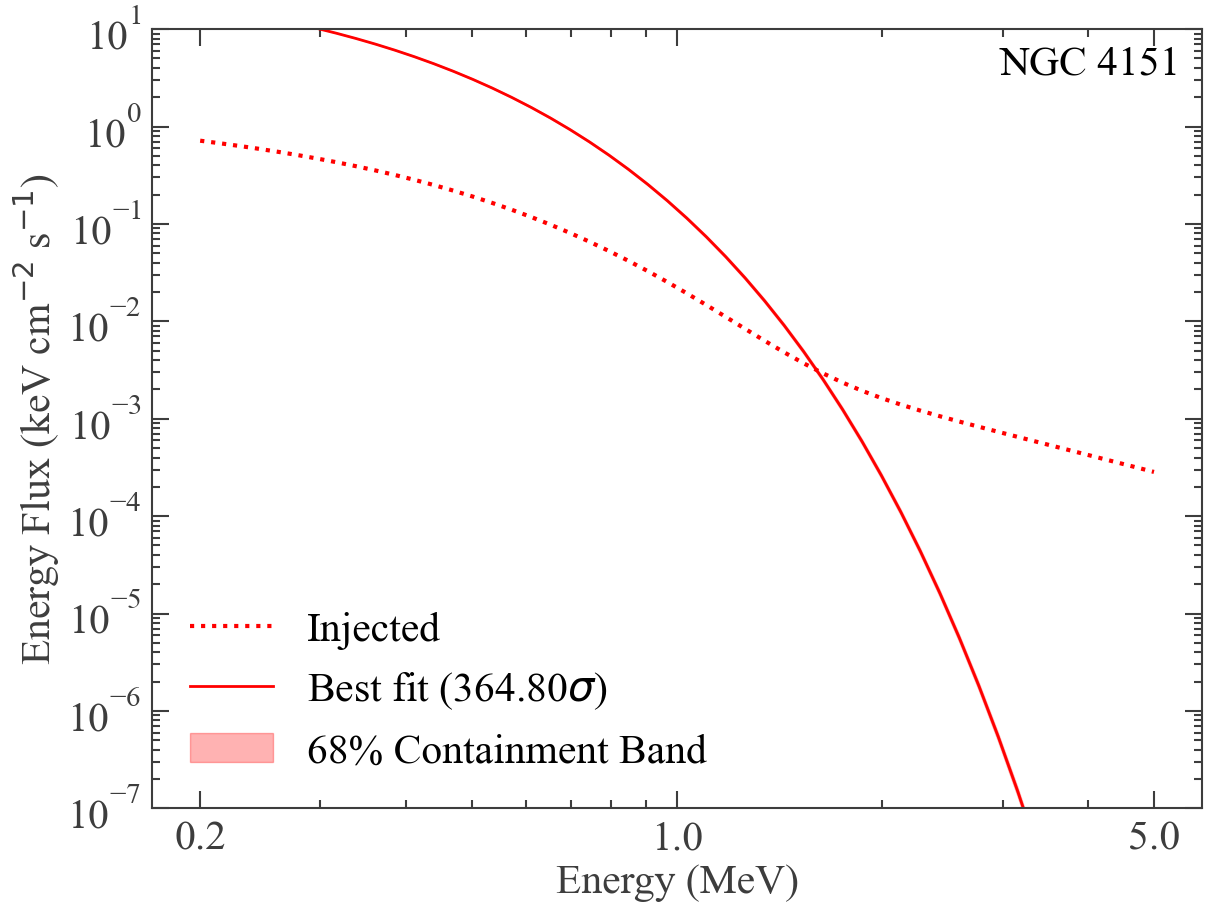

In [19]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000

plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top="on", pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top="on", pad=8)
ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right="on", pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right="on", pad=8)

ax.spines["right"].set_visible(True)
ax.spines["top"].set_visible(True)

sigma = np.sqrt(TS)
plot_color = "red" if len(fit_source_names) == 1 else "black"

ax.plot(energy, energy * energy * flux_inj, color=plot_color, ls=":", lw=3, label="Injected")
ax.plot(energy, energy * energy * flux_median, color=plot_color, label=f"Best fit ({sigma:.2f}$\\sigma$)")
ax.fill_between(
    energy,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.3,
    color=plot_color,
    label="68% Containment Band",
)

colors = {"ngc4151": "red", "ngc1068": "blue"}
if len(fit_source_names) > 1 or fit_include_nonthermal_tail:
    for name in fit_source_names:
        settings = source_settings[name]
        thermal_name = f"{name}_thermal"
        tail_name = f"{name}_tail"
        ax.plot(
            energy,
            energy * energy * source_flux_inj[name],
            color=colors[name],
            ls=":",
            lw=2,
            label=f"{settings['label']} injected",
        )
        ax.plot(
            energy,
            energy * energy * component_flux_median[thermal_name],
            color=colors[name],
            ls="--",
            lw=2,
            label=f"{settings['label']} thermal fit",
        )
        if tail_name in component_flux_median:
            ax.plot(
                energy,
                energy * energy * component_flux_median[tail_name],
                color=colors[name],
                ls="-.",
                lw=2,
                label=f"{settings['label']} non-thermal fit",
            )

text = " + ".join(source_settings[name]["label"] for name in fit_source_names)
ax.text(
    0.98,
    0.98,
    text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7, 10)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc="lower left", frameon=False)
plt.show()


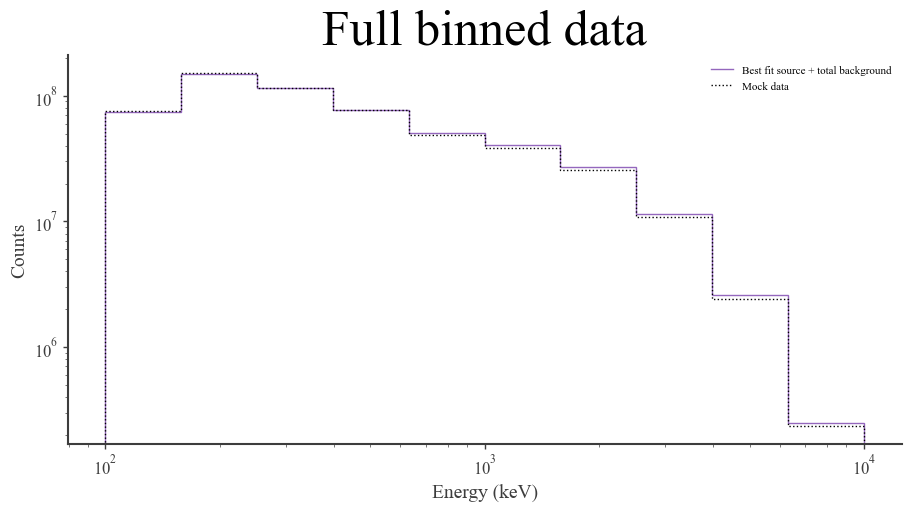

In [20]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

source_counts = expectation.project("Em").to_dense().contents
background_counts = expectation_background.project("Em").to_dense().contents
total_expectation_counts = source_counts + background_counts
data_counts = data_hist.project("Em").to_dense().contents

ax.stairs(total_expectation_counts, binned_energy_edges, color="tab:purple", label="Best fit source + total background")
ax.stairs(data_counts, binned_energy_edges, color="black", ls=":", label="Mock data")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")
ax.set_title("Full binned data")
ax.legend(frameon=False)
ax.set_xlabel("Energy (keV)")
plt.show()

## Optional profile scans

In [21]:
ngc4151_thermal_k_path = "ngc4151_thermal.spectrum.main.Cutoff_powerlaw.K"
ngc4151_thermal_xc_path = "ngc4151_thermal.spectrum.main.Cutoff_powerlaw.xc"
ngc4151_tail_idx_path = "ngc4151_tail.spectrum.main.Powerlaw.index"
ngc1068_thermal_k_path = "ngc1068_thermal.spectrum.main.Cutoff_powerlaw.K"
ngc1068_thermal_xc_path = "ngc1068_thermal.spectrum.main.Cutoff_powerlaw.xc"
ngc1068_tail_idx_path = "ngc1068_tail.spectrum.main.Powerlaw.index"


def get_profile(like, path, scale_low=None, scale_high=None, delta_low=None, delta_high=None, log=False, n_steps=40):
    best = like.likelihood_model[path].value
    pmin, pmax = like.likelihood_model[path].bounds
    pmin = -np.inf if pmin is None else pmin
    pmax = np.inf if pmax is None else pmax

    if scale_low is not None:
        low = max(best * scale_low, pmin)
    else:
        low = max(best + delta_low, pmin)

    if scale_high is not None:
        high = min(best * scale_high, pmax)
    else:
        high = min(best + delta_high, pmax)

    x, _, prof, fig = like.get_contours(
        path,
        param_1_minimum=low,
        param_1_maximum=high,
        param_1_n_steps=n_steps,
        progress=True,
        log=(log,),
    )
    delta_ts = 2 * (prof - prof.min())
    return x, delta_ts, fig

# Examples:
# x_k, dts_k, _ = get_profile(like, ngc4151_thermal_k_path, scale_low=0.3, scale_high=3.0, log=True)
# x_xc, dts_xc, _ = get_profile(like, ngc1068_thermal_xc_path, scale_low=0.3, scale_high=3.0, log=True)
# x_tail_idx, dts_tail_idx, _ = get_profile(like, ngc4151_tail_idx_path, delta_low=-1.0, delta_high=1.0)
